# 10-K Text Extraction — EDA (50-company sample)
Extracted Item 1A (Risk Factors) and Item 7 (MD&A) from FY2024 filings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from pathlib import Path

DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "filings" / "text_sections.csv")
df["item_1a_words"] = df["item_1a"].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df["item_7_words"] = df["item_7"].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
print(f"{len(df)} filings loaded")
df[["ticker", "fiscal_year", "item_1a_words", "item_7_words"]].head(10)

50 filings loaded


,ticker,fiscal_year,item_1a_words,item_7_words
0,OTIS,2024,9634,9795
1,SCI,2024,5341,2290
2,DHI,2024,9484,14777
3,ZTS,2024,20325,40770
4,ZM,2024,32104,7913
5,LSCC,2024,12212,5349
6,PSX,2024,11638,33722
7,PPL,2024,5893,35801
8,PR,2024,15972,26648
9,CLX,2024,0,0


## Missing / Empty Detection

In [2]:
print("Item 1A:")
print(f"  Missing (None):  {df['item_1a'].isna().sum()}")
print(f"  < 200 words:     {(df['item_1a_words'] < 200).sum()}")
print(f"\nItem 7:")
print(f"  Missing (None):  {df['item_7'].isna().sum()}")
print(f"  < 200 words:     {(df['item_7_words'] < 200).sum()}")

# Show any problematic extractions
short = df[(df["item_1a_words"] < 200) | (df["item_7_words"] < 200)]
if len(short):
    print(f"\n⚠ {len(short)} filings with short/missing sections:")
    print(short[["ticker", "fiscal_year", "item_1a_words", "item_7_words"]].to_string(index=False))
else:
    print("\n✓ All extractions ≥ 200 words")

Item 1A:
  Missing (None):  3
  < 200 words:     3

Item 7:
  Missing (None):  1
  < 200 words:     1

⚠ 3 filings with short/missing sections:
ticker  fiscal_year  item_1a_words  item_7_words
   CLX         2024              0             0
   OVV         2024              0         12828
  EXPD         2024              0         21315


## Word Count Summary Statistics

In [3]:
valid = df[(df["item_1a_words"] >= 200) & (df["item_7_words"] >= 200)]
print(f"Valid extractions (both ≥200 words): {len(valid)} / {len(df)}\n")
valid[["item_1a_words", "item_7_words"]].describe().round(0)

Valid extractions (both ≥200 words): 47 / 50



,item_1a_words,item_7_words
count,47.0,47.0
mean,16006.0,16397.0
std,9299.0,12344.0
min,4283.0,1935.0
25%,9746.0,6098.0
50%,12478.0,12570.0
75%,19464.0,24888.0
max,41678.0,55165.0


## Word Count Distributions

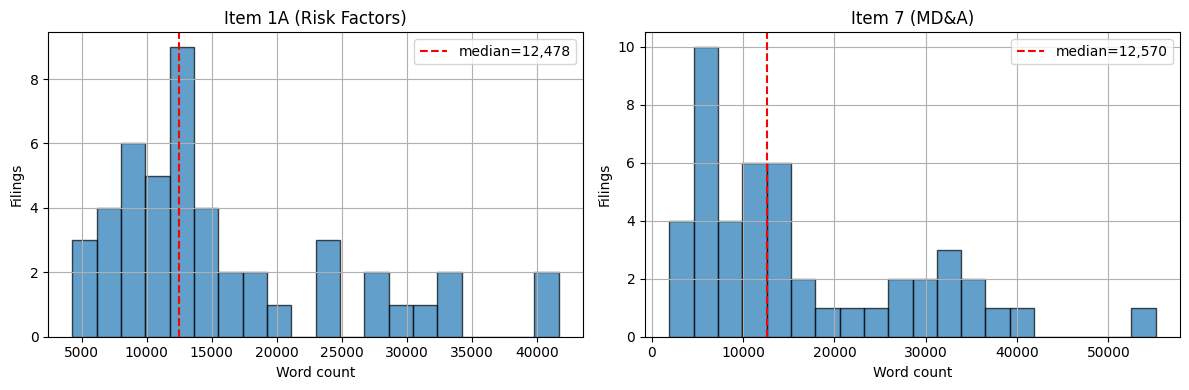

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["item_1a_words", "item_7_words"],
                            ["Item 1A (Risk Factors)", "Item 7 (MD&A)"]):
    valid[col].hist(bins=20, ax=ax, edgecolor="black", alpha=0.7)
    ax.axvline(valid[col].median(), color="red", linestyle="--", label=f"median={int(valid[col].median()):,}")
    ax.set_xlabel("Word count")
    ax.set_ylabel("Filings")
    ax.set_title(label)
    ax.legend()
plt.tight_layout()
plt.show()

## Shortest & Longest Extractions

In [5]:
for col, label in [("item_1a_words", "Item 1A"), ("item_7_words", "Item 7")]:
    s = valid.sort_values(col)
    short5 = s.head(5)[["ticker", col]]
    long5 = s.tail(5)[["ticker", col]]
    print(f"── {label}: shortest ──")
    print(short5.to_string(index=False))
    print(f"\n── {label}: longest ──")
    print(long5.to_string(index=False))
    print()

── Item 1A: shortest ──
ticker  item_1a_words
 CMCSA           4283
   SCI           5341
   PPL           5893
   SGI           6463
   CMI           7231

── Item 1A: longest ──
ticker  item_1a_words
    ZM          32104
  TRGP          32453
  DXCM          32993
   PAA          41602
  EXEL          41678

── Item 7: shortest ──
ticker  item_7_words
   DGX          1935
   SCI          2290
  TRGP          3927
  PSTG          4580
  LRCX          4780

── Item 7: longest ──
ticker  item_7_words
   PPL         35801
  FSLR         36265
   LUV         38407
   ZTS         40770
   PAA         55165



## Item 1A vs Item 7 Word Count (scatter)

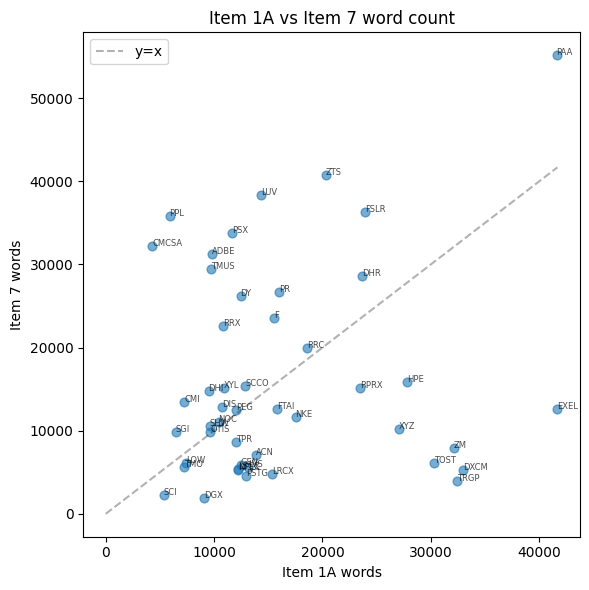

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(valid["item_1a_words"], valid["item_7_words"], alpha=0.6, s=40)
for _, r in valid.iterrows():
    ax.annotate(r.ticker, (r.item_1a_words, r.item_7_words), fontsize=6, alpha=0.7)
ax.set_xlabel("Item 1A words")
ax.set_ylabel("Item 7 words")
ax.set_title("Item 1A vs Item 7 word count")
ax.plot([0, valid["item_1a_words"].max()], [0, valid["item_1a_words"].max()],
        "k--", alpha=0.3, label="y=x")
ax.legend()
plt.tight_layout()
plt.show()

## Text Previews (first 500 chars for manual inspection)

In [7]:
# Show first 500 chars of Item 1A for 5 random companies
sample5 = valid.sample(5, random_state=42)
for _, r in sample5.iterrows():
    text = str(r.item_1a)[:500]
    print(f"═══ {r.ticker} FY{r.fiscal_year} — Item 1A ({r.item_1a_words:,} words) ═══")
    print(text)
    print("…\n")

═══ SGI FY2024 — Item 1A (6,463 words) ═══
ITEM 1A. RISK FACTORS
The following risk factors and other information included in this Report should be carefully considered. Please also see "Special Note Regarding Forward-Looking Statements" on page 
3
.
Risks related to our Business and Economic Environment
We operate in a highly competitive industry and if we are unable to compete successfully, we may lose customers and our sales may decline.
Participants in the mattress and pillow industries compete primarily on price, quality, brand name
…

═══ NOC FY2024 — Item 1A (10,410 words) ═══
Item 1A. Risk Factors
Our consolidated financial position, results of operations and cash flows are subject to various risks, many of which are not exclusively within our control, that may cause actual performance to differ materially from historical or projected future performance. We encourage you to consider carefully the risk factors described below in evaluating the information contained in this repor

In [8]:
# Show first 500 chars of Item 7 for same companies
for _, r in sample5.iterrows():
    text = str(r.item_7)[:500]
    print(f"═══ {r.ticker} FY{r.fiscal_year} — Item 7 ({r.item_7_words:,} words) ═══")
    print(text)
    print("…\n")

═══ SGI FY2024 — Item 7 (9,864 words) ═══
ITEM 7. MANAGEMENT'S DISCUSSION AND ANALYSIS OF FINANCIAL CONDITION AND RESULTS OF OPERATIONS
The following discussion and analysis should be read in conjunction with the audited Consolidated Financial Statements and accompanying notes thereto included elsewhere in this Report. Unless otherwise noted, all of the financial information in this Report is consolidated financial information for the Company, excluding Mattress Firm unless otherwise noted. The forward-looking statements in this discuss
…

═══ NOC FY2024 — Item 7 (11,006 words) ═══
Item 7. Management’s Discussion and Analysis of Financial Condition and Results of Operations
OVERVIEW
The following discussion should be read along with the financial statements included in this Form 10-K, as well as Part II, “Item 7. Management's Discussion and Analysis of Financial Condition and Results of Operations” (MD&A) of our Form 10-K for the year ended December 31, 2023 (“2023 Annual Report on For

## Quality Checks (artifacts, HTML remnants, encoding issues)

In [9]:
def quality_flags(text):
    """Check for common extraction artifacts."""
    if pd.isna(text):
        return {"html_tags": False, "encoding_issues": False, "excessive_whitespace": False}
    t = str(text)
    return {
        "html_tags": bool(re.search(r"<[a-z]+[\s>]", t, re.IGNORECASE)),
        "encoding_issues": bool(re.search(r"[\x00-\x08\x0b\x0c\x0e-\x1f]|â€|Ã|\\u00", t)),
        "excessive_whitespace": bool(re.search(r" {5,}", t)),
    }

flags_1a = df["item_1a"].apply(quality_flags).apply(pd.Series)
flags_7 = df["item_7"].apply(quality_flags).apply(pd.Series)
print("Item 1A quality flags:")
print(flags_1a.sum().to_string())
print(f"\nItem 7 quality flags:")
print(flags_7.sum().to_string())

# Show tickers with HTML remnants
html_flagged = df.loc[flags_1a["html_tags"] | flags_7["html_tags"], "ticker"]
if len(html_flagged):
    print(f"\n⚠ HTML remnants found in: {list(html_flagged)}")
else:
    print("\n✓ No HTML remnants detected")

Item 1A quality flags:
html_tags               0
encoding_issues         0
excessive_whitespace    0

Item 7 quality flags:
html_tags               0
encoding_issues         0
excessive_whitespace    0

✓ No HTML remnants detected


## Top 30 Words (stopwords removed)

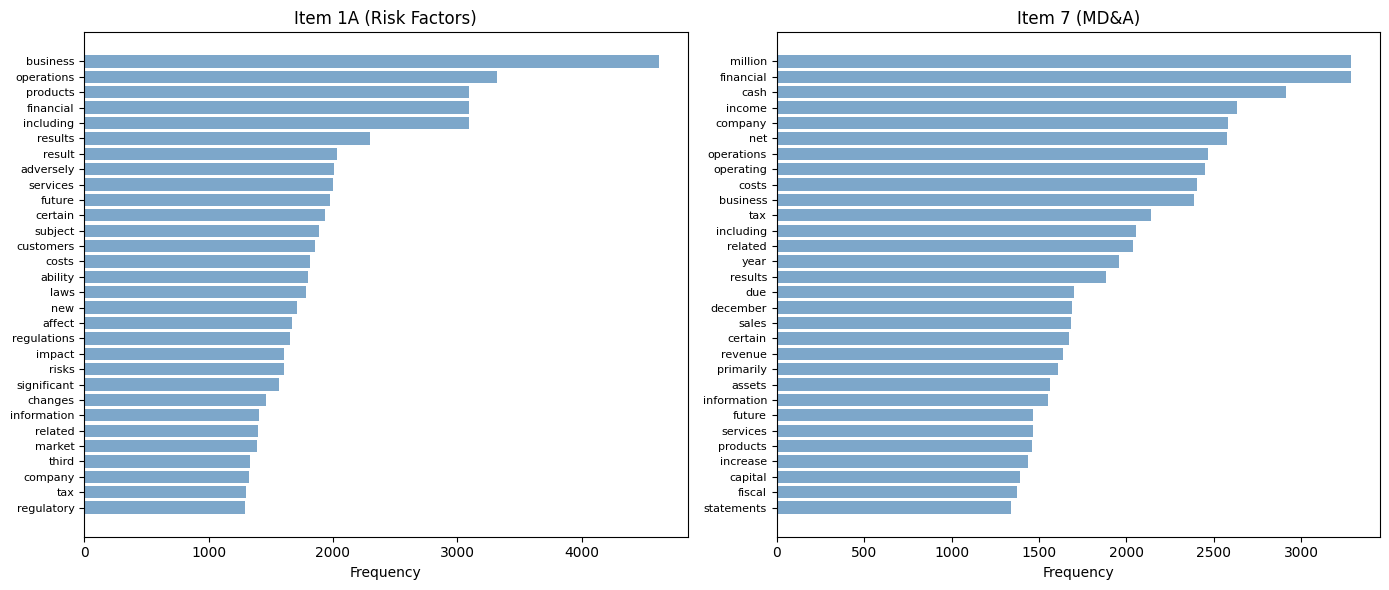

In [10]:
STOPWORDS = set("the a an and or but in on of to for is it its that this with are was were be been "
                "by from at as our we us have has had may will would could can their which not no "
                "been such also more than other each any all these those into if about over between "
                "through under there out up so them some what they who how much many".split())

def top_words(series, n=30):
    text = " ".join(series.dropna().astype(str)).lower()
    words = re.findall(r"\b[a-z]{3,}\b", text)
    return Counter(w for w in words if w not in STOPWORDS).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, label in zip(axes, ["item_1a", "item_7"],
                            ["Item 1A (Risk Factors)", "Item 7 (MD&A)"]):
    top = top_words(valid[col])
    words, counts = zip(*top)
    ax.barh(range(len(words)), counts, color="steelblue", alpha=0.7)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(label)
    ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

## Full Overview Table

In [11]:
overview = df[["ticker", "fiscal_year", "item_1a_words", "item_7_words"]].copy()
overview["status"] = "ok"
overview.loc[overview["item_1a_words"] < 200, "status"] = "⚠ 1A short"
overview.loc[overview["item_7_words"] < 200, "status"] = "⚠ 7 short"
overview.loc[(overview["item_1a_words"] < 200) & (overview["item_7_words"] < 200), "status"] = "⚠ both short"
pd.set_option("display.max_rows", 60)
overview.sort_values("ticker")

,ticker,fiscal_year,item_1a_words,item_7_words,status
11,ACN,2024,13843,7116,ok
16,ADBE,2024,9801,31222,ok
9,CLX,2024,0,0,⚠ both short
20,CMCSA,2024,4283,32203,ok
18,CMI,2024,7231,13502,ok
47,DGX,2024,9065,1935,ok
2,DHI,2024,9484,14777,ok
32,DHR,2024,23631,28622,ok
45,DIS,2024,10741,12865,ok
23,DXCM,2024,32993,5255,ok
